Import Libraries 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

Load Dataset

In [4]:
df = pd.read_csv("D:\Projects\Python_projects\Machine_Learning\CodeAlpha\Sales Prediction\Advertising.csv")
print('Header',df.head())
print('Summary data', df.describe())
print('Checking for missing value',df.info())

Header    Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
Summary data        Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      

Data Cleaning and Feature Selection

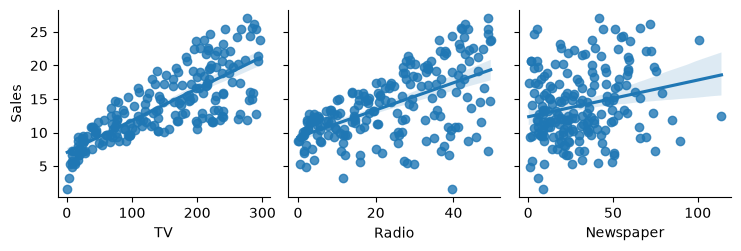

In [9]:
#df.isnull().sum()
#Generate a pairplot 
#to visualize the linear relationships between advertising spends and sales.
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', kind='reg')


Train the Regression Model

# Select features (X) and target variable (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Multiple Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

Evaluation and Business Insights

In [11]:
# Predict and evaluate
y_pred = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Display coefficients to analyze impact
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients)

R-squared Score: 0.8994
RMSE: 1.7816
     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


TV (0.0447): While TV has a lower coefficient value per dollar spent compared to Radio, keep in mind that total TV budgets are typically much higher. It remains a major volume driver.   
Radio (0.1892): This is the highest coefficient. It shows that Radio advertising yields the strongest return on investment per dollar spent compared to the other channels.   
Newspaper (0.0028): This coefficient is practically close to zero, confirming your earlier pairplot observation that newspaper advertising has a negligible impact on sales.  